# 🎓 Student Exam Score Prediction Using Machine Learning

## Project Overview

This project aims to build a machine learning model to predict students' exam scores based on various academic, behavioral, demographic, and socioeconomic factors. The complete machine learning workflow is covered, including data exploration, preprocessing, model comparison, cross-validation, and final evaluation.


## **Importing the required Libraries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    SGDRegressor
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

## **Load and explore data**

In [3]:
!pip install -q kagglehub

import kagglehub
import os

path = kagglehub.dataset_download(
    "lainguyn123/student-performance-factors"
)

print("Dataset downloaded to:")
print(path)

print("\nFiles:")
print(os.listdir(path))

100%|██████████| 93.9k/93.9k [00:00<00:00, 42.9MB/s]

Extracting files...
Dataset downloaded to:
/root/.cache/kagglehub/datasets/lainguyn123/student-performance-factors/versions/9

Files:
['StudentPerformanceFactors.csv']


In [4]:
file_path = os.path.join(
    path,
    "StudentPerformanceFactors.csv"
)

df = pd.read_csv(file_path)

display(df.head())

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [5]:
print("Shape:", df.shape)

print("\nDataset information:")
df.info()

Shape: (6607, 20)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Inf

In [ ]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [ ]:
print("\nDuplicate rows:")
print(df.duplicated().sum())


Duplicate rows:
0


In [ ]:
print("\nStatistical summary:")
display(df.describe())


Statistical summary:


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## **Separating X and y**

In [6]:
X = df.drop(['Exam_Score'], axis=1)
y = df['Exam_Score']

In [ ]:
X.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female


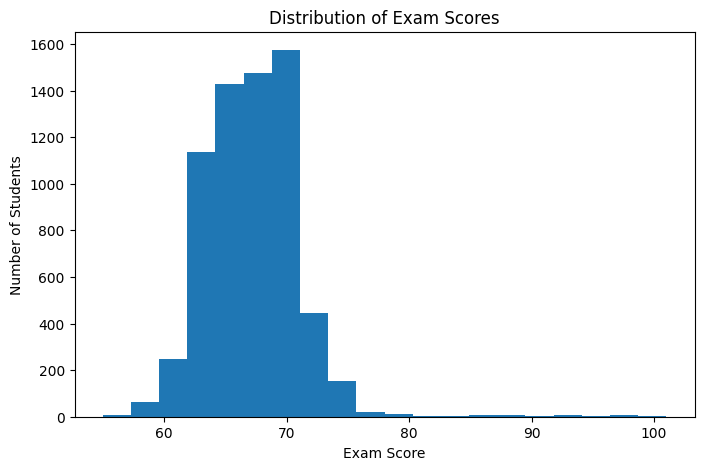

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(y, bins=20)

plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Exam Scores")

plt.show()

## **Correlations of the features with the target feature**

In [7]:
numeric_df = df.select_dtypes(include="number")

correlations = (
    numeric_df
    .corr()["Exam_Score"]
    .sort_values(ascending=False)
)

print(correlations)

Exam_Score           1.000000
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64


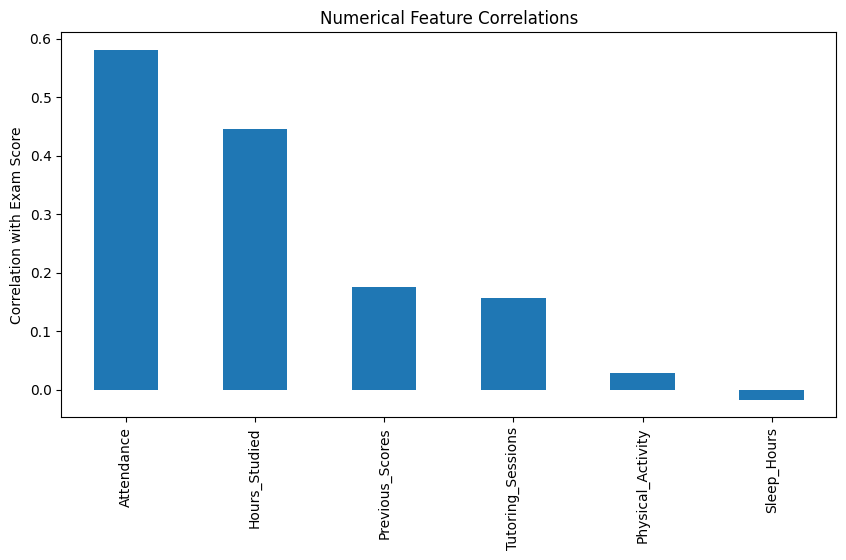

In [ ]:
correlations.drop("Exam_Score").plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("Correlation with Exam Score")
plt.title("Numerical Feature Correlations")

plt.show()

In [ ]:
print(
    df.groupby("Motivation_Level")["Exam_Score"]
    .mean()
    .sort_values()
)

Motivation_Level
Low       66.752194
Medium    67.330648
High      67.704321
Name: Exam_Score, dtype: float64


In [ ]:
print(
    df.groupby("Parental_Involvement")["Exam_Score"]
    .mean()
    .sort_values()
)

Parental_Involvement
Low       66.358265
Medium    67.098156
High      68.092767
Name: Exam_Score, dtype: float64


In [ ]:
print(
    df.groupby("Teacher_Quality")["Exam_Score"]
    .mean()
    .sort_values()
)

Teacher_Quality
Low       66.753425
Medium    67.109299
High      67.676939
Name: Exam_Score, dtype: float64


## **Splitting the dataset into train and test sets**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=13
)

## **Handling the numerical and categorical features**

In [9]:
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns

print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical features:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [10]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [11]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

In [12]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

## **Calculating baseline**

In [13]:
baseline_predictions = np.full(
    len(y_train),
    y_train.mean()
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_train,
    baseline_predictions
)

print("Baseline RMSE:", baseline_rmse)
print("Baseline r2:", baseline_r2)

Baseline RMSE: 3.8974230121346585
Baseline r2: 0.0


## **Comparing different algorithms**

### **Finding the best parameters for different algorithms using GridSearchCV**

In [20]:
sgd_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('sgd_model', SGDRegressor())
])

sgd_params = {
    'sgd_model__alpha' : [0.1, 1, 2],
    'sgd_model__penalty' : ["l1", "l2"],
    'sgd_model__eta0' : [0.01, 0.1, 1],
    'sgd_model__learning_rate' : ["constant", "optimal"],
    'sgd_model__max_iter': [3000, 3100]
}

sgd_grid = GridSearchCV(
    sgd_pipeline, sgd_params, cv=5, scoring="neg_mean_squared_error", n_jobs = -1
)

sgd_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity'],
      dtype='object')),
                                                                        ('categorical',
                                                                         Pipeline(steps=...
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object'))])),
                                       ('sgd_model', SGDRegressor())]),
             n_jobs=-1,
             param_grid={'sgd_model__alpha': [0.1, 1, 2],
                         'sgd_model__eta0': [0.01, 0.1, 1],
                         'sgd_model__learning_rate': ['constant', 'optimal'],
                         'sgd_model__max_iter': [3000, 3100],
                         'sgd_model__penalty': ['l1', 'l2']},
             scoring='neg_mean_squared_error')

In [21]:
print("best parameters for SGDRegressor:")
print(sgd_grid.best_params_)

print("\nbest score for SGDRegressor:")
print(np.sqrt(-sgd_grid.best_score_))

best parameters for SGDRegressor:
{'sgd_model__alpha': 0.1, 'sgd_model__eta0': 0.01, 'sgd_model__learning_rate': 'constant', 'sgd_model__max_iter': 3100, 'sgd_model__penalty': 'l2'}

best score for SGDRegressor:
2.1714530576987943


In [ ]:
lasso_pipeline = Pipeline(
    [
        ("preprocessor" , preprocessor),
        ("lasso_model" , Lasso())
    ]
)

lasso_params = {
    "lasso_model__alpha" : [0.0001, 0.001, 0.01, 0.1],
    "lasso_model__max_iter" : [800, 1000, 2000],
}

lasso_grid = GridSearchCV(
    lasso_pipeline, lasso_params, cv=5, scoring="neg_mean_squared_error", n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity'],
      dtype='object')),
                                                                        ('categorical',
                                                                         Pipeline(steps=...
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object'))])),
                                       ('lasso_model', Lasso())]),
             n_jobs=-1,
             param_grid={'lasso_model__alpha': [0.0001, 0.001, 0.01, 0.1],
                         'lasso_model__max_iter': [800, 1000, 2000]},
             scoring='neg_mean_squared_error')

In [ ]:
print("best parameters for lasso:")
print(lasso_grid.best_params_)

print("\nbest score for lasso:")
print(np.sqrt(-lasso_grid.best_score_))

best parameters for lasso:
{'lasso_model__alpha': 0.001, 'lasso_model__max_iter': 800}

best score for lasso:
2.0107214866656844


In [15]:
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("ridge_model", Ridge())
])

ridge_params = {
    "ridge_model__alpha": [3, 4, 5],
    "ridge_model__max_iter": [100, 200, 300]
}

ridge_grid = GridSearchCV(
    ridge_pipeline, ridge_params, cv=5, scoring="neg_mean_squared_error", n_jobs=-1
)

ridge_grid.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity'],
      dtype='object')),
                                                                        ('categorical',
                                                                         Pipeline(steps=...
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object'))])),
                                       ('ridge_model', Ridge())]),
             n_jobs=-1,
             param_grid={'ridge_model__alpha': [3, 4, 5],
                         'ridge_model__max_iter': [100, 200, 300]},
             scoring='neg_mean_squared_error')

In [16]:
print('best parameters for ridge:')
print(ridge_grid.best_params_)

print("\nbest score for ridge:")
print(np.sqrt(-ridge_grid.best_score_))

best parameters for ridge:
{'ridge_model__alpha': 5, 'ridge_model__max_iter': 100}

best score for ridge:
2.0106885021033927


In [ ]:
RF_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("RF_model", RandomForestRegressor())
])

RF_params = {
    "RF_model__n_estimators": [50, 100, 150],
    "RF_model__max_depth": [10, 20],
    "RF_model__min_samples_split": [5, 10, 15],
    "RF_model__min_samples_leaf": [2, 5, 7]
}

RF_grid = GridSearchCV(
    RF_pipeline, RF_params, cv=5, scoring= "neg_mean_squared_error", n_jobs=-1
)

RF_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity'],
      dtype='object')),
                                                                        ('categorical',
                                                                         Pipeline(steps=...
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object'))])),
                                       ('RF_model', RandomForestRegressor())]),
             n_jobs=-1,
             param_grid={'RF_model__max_depth': [10, 20],
                         'RF_model__min_samples_leaf': [2, 5, 7],
                         'RF_model__min_samples_split': [5, 10, 15],
                         'RF_model__n_estimators': [50, 100, 150]},
             scoring='neg_mean_squared_error')

In [ ]:
RF_best_params = RF_grid.best_params_

print("best parameters for RandomForest:")
print(RF_best_params)

print("\nbest score for RandomForest:")
print(np.sqrt(-RF_grid.best_score_))

best parameters for RandomForest:
{'RF_model__max_depth': 20, 'RF_model__min_samples_leaf': 2, 'RF_model__min_samples_split': 5, 'RF_model__n_estimators': 100}

best score for RandomForest:
2.310133770620855


In [ ]:
linear_pipeline = Pipeline([(
    'preprocessor', preprocessor),
    ('linear_model', LinearRegression())
])

linear_params = {
    'linear_model__fit_intercept': [True, False]
}

linear_grid = GridSearchCV(
    linear_pipeline, linear_params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
)

linear_grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity'],
      dtype='object')),
                                                                        ('categorical',
                                                                         Pipeline(steps=...
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object'))])),
                                       ('linear_model', LinearRegression())]),
             n_jobs=-1,
             param_grid={'linear_model__fit_intercept': [True, False]},
             scoring='neg_root_mean_squared_error')

In [ ]:
print('best parameters for linear regression:')
print(linear_grid.best_params_)

print("\nbest score for linear regression:")
print(np.sqrt(-linear_grid.best_score_))

best parameters for linear regression:
{'linear_model__fit_intercept': True}

best score for linear regression:
1.4132709603500948


### **Comparison of the models**

In [ ]:
models = {
    "Linear Regression": linear_pipeline,
    "Ridge": ridge_grid.best_estimator_,
    "Lasso": lasso_grid.best_estimator_,
    "SGD": sgd_grid.best_estimator_,
    "Random Forest": RF_grid.best_estimator_
}


results = []

for name, model in models.items():

    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )

    cv_rmse = -cv_scores.mean()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    test_rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    test_mae = mean_absolute_error(
        y_test,
        y_pred
    )

    test_r2 = r2_score(
        y_test,
        y_pred
    )

    results.append({
        "Model": name,
        "CV RMSE": cv_rmse,
        "Test RMSE": test_rmse,
        "Test MAE": test_mae,
        "Test R²": test_r2
    })


results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="CV RMSE"
).reset_index(drop=True)

results_df

,Model,CV RMSE,Test RMSE,Test MAE,Test R²
0,Ridge,1.997306,2.163349,0.499006,0.686054
1,Linear Regression,1.997335,2.163427,0.498980,0.686032
2,Lasso,1.997351,2.163081,0.498981,0.686132
3,SGD,2.108516,2.270786,0.743220,0.654097
4,Random Forest,2.312431,2.443757,1.144396,0.599394


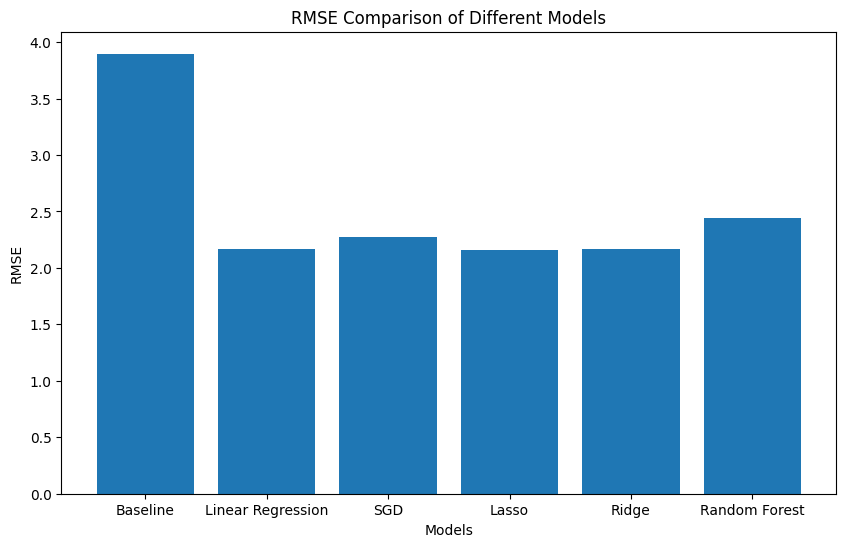

In [ ]:
plt.figure(figsize=(10, 6))

# Extract Test RMSE values from results_df for each model
linear_reg_rmse = results_df[results_df['Model'] == 'Linear Regression']['Test RMSE'].values[0]
sgd_rmse = results_df[results_df['Model'] == 'SGD']['Test RMSE'].values[0]
lasso_rmse = results_df[results_df['Model'] == 'Lasso']['Test RMSE'].values[0]
ridge_rmse = results_df[results_df['Model'] == 'Ridge']['Test RMSE'].values[0]
random_forest_rmse = results_df[results_df['Model'] == 'Random Forest']['Test RMSE'].values[0]

plt.bar(['Baseline', 'Linear Regression', 'SGD', 'Lasso', 'Ridge', 'Random Forest'],
        [baseline_rmse, linear_reg_rmse, sgd_rmse, lasso_rmse, ridge_rmse, random_forest_rmse])
plt.title('RMSE Comparison of Different Models')
plt.ylabel('RMSE')
plt.xlabel('Models')
plt.show()

## **Find the best model**

In [ ]:
best_model = results_df.iloc[0]

print("Best Model:")
print(best_model)

Best Model:
Model           Ridge
CV RMSE      1.997306
Test RMSE    2.163349
Test MAE     0.499006
Test R²      0.686054
Name: 0, dtype: object


## **Checking our best model -- Ridge, for overfitting**

In [17]:
my_best_model = ridge_grid.best_estimator_

train_predictions = my_best_model.predict(X_train)
test_predictions = my_best_model.predict(X_test)

ridge_r2 = r2_score(y_test, test_predictions)

print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, train_predictions))}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, test_predictions))}")

print(f"\nBaseline r2: {baseline_r2}")
print(f"Ridge r2: {ridge_r2}")

Train RMSE: 1.9989121993174404
Test RMSE: 2.1633485411726237

Baseline r2: 0.0
Ridge r2: 0.6860541882053806


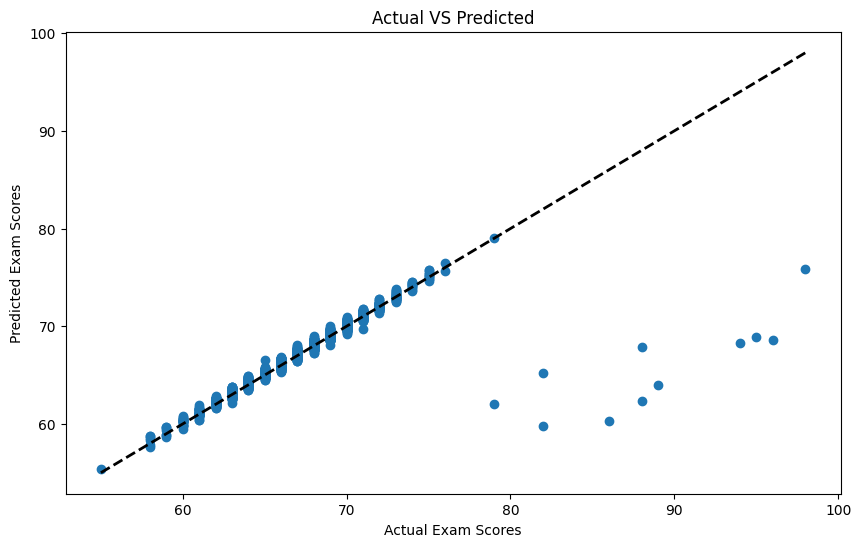

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, test_predictions)
plt.xlabel("Actual Exam Scores")
plt.ylabel("Predicted Exam Scores")
plt.title("Actual VS Predicted")

# Add a diagonal line for perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.show()

## **Final evaluation of the best model**

In [18]:
cv_ridge_scores = cross_val_score(
    my_best_model,
    X_train,
    y_train,
    scoring="neg_root_mean_squared_error",
    cv=5
)

cv_ridge_scores = -cv_ridge_scores

print("Ridge CV RMSE scores:", cv_ridge_scores)
print("Mean CV RMSE:", cv_ridge_scores.mean())

Ridge CV RMSE scores: [2.23825056 2.31852329 1.82797919 1.77729726 1.82448129]
Mean CV RMSE: 1.997306317959805


In [19]:
import joblib

joblib.dump(my_best_model, 'best_model.pkl')

['best_model.pkl']

## **Project Summary and Conclusion**

This project aimed to predict student exam scores using various academic, behavioral, demographic, and socioeconomic factors. We performed a comprehensive machine learning workflow:

1.  **Data Loading and Exploration:** Initial analysis revealed insights into data distributions, missing values, and feature correlations.
2.  **Data Preprocessing:** Numerical features were scaled, and categorical features were one-hot encoded, with missing values handled appropriately.
3.  **Baseline Model:** A simple baseline model was established using the mean of the training target to provide a reference for performance.
4.  **Model Training and Hyperparameter Tuning:** Several regression models (Linear Regression, Ridge, Lasso, SGDRegressor, Random Forest) were trained and optimized using GridSearchCV to find their best hyperparameters.
5.  **Model Comparison:** All trained models were compared based on their Cross-Validation RMSE, Test RMSE, MAE, and R² scores. The `results_df` showed:
    *   **Ridge Regression** performed best overall with the lowest CV RMSE and Test RMSE (approximately 1.99 and 2.16 respectively), along with the highest R² score (around 0.686).
    *   **Linear Regression** and **Lasso Regression** also showed very similar performance to Ridge Regression.
    *   **Random Forest** had the highest RMSE among the tested models.
6.  **Best Model Selection and Evaluation:** Ridge Regression was selected as the best model. Its performance on the test set (`Test RMSE: 2.16`, `Ridge R2: 0.686`) significantly outperformed the baseline (`Baseline RMSE: 3.89`, `Baseline R2: 0.0`). Cross-validation scores further confirmed its consistent performance.

**Conclusion:**
The Ridge Regression model effectively predicts student exam scores, demonstrating good accuracy and generalization capabilities. The 'Actual vs Predicted' plot shows a strong correlation, with predictions clustering well around the ideal diagonal line, indicating reliable performance.